# Gestion des espaces verts à Paris : problématiques et objectifs

## Problématiques actuelles
La gestion des espaces verts à Paris rencontre des problèmes liés à l'absence d'informations à jour sur l'état des arbres, à une répartition inefficace des ressources pour leur entretien, ainsi qu'à un manque d'outils de prévision et de planification des travaux. Cela entraîne une augmentation des coûts, un retrait tardif des arbres dangereux et une végétalisation insuffisante dans certains quartiers, ce qui nécessite la mise en place de solutions numériques pour le suivi, l'automatisation et l'optimisation de tous les processus.

---

## Objectif du projet
L'objectif du projet est de développer un système de gestion des espaces verts à Paris, qui permettra une répartition efficace des ressources, une réduction des coûts et un renforcement de la durabilité écologique de la ville. Ce système devra prendre en compte trois aspects clés : 
1. L'entretien des arbres.  
2. La plantation de nouvelles espèces.  
3. La planification prédictive.  

---

## Importance de l'amélioration des données
Pour résoudre efficacement le problème et concevoir un système de gestion des espaces verts à Paris, il est essentiel d'améliorer la qualité de votre base de données, car elle constitue la base de la prise de décision.

---

## Questions clés à explorer
1. **Quels critères sont utilisés pour identifier les arbres dangereux ? Comment leur retrait est-il planifié ?**
2. **Quels quartiers nécessitent une végétalisation accrue ? Existe-t-il des directives pour le choix des espèces à planter ?**
3. **À quelle fréquence l'état des arbres est-il surveillé ? Est-il possible d'automatiser cette tâche ?**
4. **Quelles ressources (financières, temporelles, humaines) sont les plus limitées ?**




## Analyse des problématiques liées à la gestion des espaces verts à Paris

### Critères pour identifier les arbres dangereux
- **Données utiles :**
  - `circonference_cm` (circonférence de l'arbre) et `hauteur_m` (hauteur de l'arbre) : Les arbres très grands ou ayant une circonférence excessive pourraient présenter un risque.
  - `stade_developpement` (stade de développement) : Les arbres âgés sont plus susceptibles d’être fragiles ou instables.
  - `remarquable` : Cette variable peut être utilisée pour prioriser les arbres ayant une valeur historique ou écologique.

- **Méthodes d'analyse :**
  - Filtrer les arbres avec une hauteur ou une circonférence anormalement élevées.
  - Identifier les arbres dans des stades de développement avancés comme candidats au retrait.
  - Utiliser les données de localisation (`geo_point_2d_a`, `geo_point_2d_b`) pour cartographier les arbres dangereux.

- **Planification de l’enlèvement :**
  - Créer une liste prioritaire d'arbres à inspecter.
  - Utiliser les coordonnées géographiques pour optimiser les itinéraires des équipes d’entretien.

---

### Zones nécessitant davantage de végétalisation
- **Données utiles :**
  - `arrondissement` : Analyser le nombre d'arbres par arrondissement pour identifier les zones sous-végétalisées.
  - `type_emplacement` : Identifier les types d’emplacement (parcs, rues) ayant le moins d’arbres.

- **Analyse :**
  - Regrouper les données par arrondissement et comptabiliser le nombre d'arbres.
  - Comparer les densités de végétation entre les arrondissements.

- **Choix des espèces à planter :**
  - Utiliser `genre`, `espece` et `variete` pour sélectionner des espèces adaptées au climat parisien et résistantes aux conditions locales.
  - Tenir compte des contraintes écologiques et esthétiques des zones concernées.

---

### Fréquence de surveillance et automatisation
- **Données utiles :**
  - `stade_developpement` : Les arbres en croissance ou dans un stade avancé nécessitent une surveillance fréquente.
  - `geo_point_2d_a` et `geo_point_2d_b` : Ces coordonnées facilitent la création de plans de surveillance géographique.

- **Automatisation :**
  - Utiliser des drones pour une inspection visuelle des arbres en hauteur.
  - Installer des capteurs IoT pour surveiller en temps réel l’humidité du sol et la santé des arbres.
  - Mettre en place des plans dynamiques basés sur l'évolution des conditions des arbres.

---

### Ressources limitées
- **Données utiles :**
  - `domanialite` : Identifier les espaces sous gestion publique et ceux nécessitant des investissements.
  - `circonference_cm` et `hauteur_m` : Ces variables peuvent aider à prioriser les arbres en fonction de l'effort requis pour leur entretien.

- **Analyse :**
  - Évaluer les arrondissements nécessitant davantage de ressources en fonction de la densité et de l'état des arbres.
  - Analyser le type d'entretien (abattage, élagage, plantation) demandant le plus de temps et de coûts.

- **Priorisation :**
  - Distribuer les équipes d’entretien en fonction des besoins réels par zone.
  - Optimiser l’allocation des ressources financières et humaines.

---

In [92]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.express as px
import squarify  # Library for Treemap visualization
import folium
from folium.plugins import MarkerCluster
from IPython.display import display

## 1. Chargement des données

In [3]:
# Define folder and file paths
chemin_dossier = r"C:\Users\darya\Desktop\OpenClassRooms\Project 02"
nom_fichier = "p2-arbres-fr.csv"
chemin_fichier = os.path.join(chemin_dossier, nom_fichier)

In [4]:
# Read the CSV file
df = pd.read_csv(chemin_fichier, sep=";")

## 2. Vision générale du jeu de données

* Nombre de lignes et colonnes

In [7]:
df.shape

(200137, 18)

* Noms des Colonnes

In [9]:
df.columns

Index(['id', 'type_emplacement', 'domanialite', 'arrondissement',
       'complement_addresse', 'numero', 'lieu', 'id_emplacement',
       'libelle_francais', 'genre', 'espece', 'variete', 'circonference_cm',
       'hauteur_m', 'stade_developpement', 'remarquable', 'geo_point_2d_a',
       'geo_point_2d_b'],
      dtype='object')

* Types de Données par Colonne

In [11]:
df.dtypes

id                       int64
type_emplacement        object
domanialite             object
arrondissement          object
complement_addresse     object
numero                 float64
lieu                    object
id_emplacement          object
libelle_francais        object
genre                   object
espece                  object
variete                 object
circonference_cm         int64
hauteur_m                int64
stade_developpement     object
remarquable            float64
geo_point_2d_a         float64
geo_point_2d_b         float64
dtype: object

* Informations générales:

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200137 entries, 0 to 200136
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   200137 non-null  int64  
 1   type_emplacement     200137 non-null  object 
 2   domanialite          200136 non-null  object 
 3   arrondissement       200137 non-null  object 
 4   complement_addresse  30902 non-null   object 
 5   numero               0 non-null       float64
 6   lieu                 200137 non-null  object 
 7   id_emplacement       200137 non-null  object 
 8   libelle_francais     198640 non-null  object 
 9   genre                200121 non-null  object 
 10  espece               198385 non-null  object 
 11  variete              36777 non-null   object 
 12  circonference_cm     200137 non-null  int64  
 13  hauteur_m            200137 non-null  int64  
 14  stade_developpement  132932 non-null  object 
 15  remarquable      

* Aperçu des cinq premières lignes

In [15]:
df.head()

,id,type_emplacement,domanialite,arrondissement,complement_addresse,numero,lieu,id_emplacement,libelle_francais,genre,espece,variete,circonference_cm,hauteur_m,stade_developpement,remarquable,geo_point_2d_a,geo_point_2d_b
0,99874,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,19,Marronnier,Aesculus,hippocastanum,NaN,20,5,NaN,0.0,48.857620,2.320962
1,99875,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,20,If,Taxus,baccata,NaN,65,8,A,NaN,48.857656,2.321031
2,99876,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,21,If,Taxus,baccata,NaN,90,10,A,NaN,48.857705,2.321061
3,99877,Arbre,Jardin,PARIS 7E ARRDT,NaN,NaN,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,22,Erable,Acer,negundo,NaN,60,8,A,NaN,48.857722,2.321006
4,99878,Arbre,Jardin,PARIS 17E ARRDT,NaN,NaN,PARC CLICHY-BATIGNOLLES-MARTIN LUTHER KING,000G0037,Arbre à miel,Tetradium,daniellii,NaN,38,0,NaN,NaN,48.890435,2.315289


In [16]:
# Count of missing values for each column
# Calculate the count of missing values for each column
valeurs_manquantes = df.isnull().sum()
# Filter only the columns with missing values
colonnes_manquantes = valeurs_manquantes[valeurs_manquantes > 0]

# Sort the columns by the count of missing values in descending order
colonnes_manquantes = colonnes_manquantes.sort_values(ascending=False)

# Percentage of missing values for each column
pourcentage_manquantes = (df.isnull().sum() / len(df)) * 100
pourcentage_manquantes = pourcentage_manquantes.sort_values(ascending=False)
print("\nPourcentage de valeurs manquantes par colonne:")
print(pourcentage_manquantes)

# Sort the columns by the count of missing values in descending order
print("\nColonnes avec des valeurs manquantes:")
print(colonnes_manquantes)



Pourcentage de valeurs manquantes par colonne:
numero                 100.000000
complement_addresse     84.559577
variete                 81.624088
stade_developpement     33.579498
remarquable             31.527404
espece                   0.875400
libelle_francais         0.747988
genre                    0.007995
domanialite              0.000500
circonference_cm         0.000000
geo_point_2d_a           0.000000
hauteur_m                0.000000
id                       0.000000
type_emplacement         0.000000
id_emplacement           0.000000
lieu                     0.000000
arrondissement           0.000000
geo_point_2d_b           0.000000
dtype: float64

Colonnes avec des valeurs manquantes:
numero                 200137
complement_addresse    169235
variete                163360
stade_developpement     67205
remarquable             63098
espece                   1752
libelle_francais         1497
genre                      16
domanialite                 1
dtype: int64


* Supprimer les colonnes inutiles (complement_addresse et numero) et créer un nouveau DataFrame.

In [18]:
#Remove unnecessary columns ('complement_addresse' and 'numero') and create a new DataFrame
df01 = df.drop(columns=['complement_addresse', 'numero'])  # Drop specified columns

In [19]:
# Drop rows with missing values in 'genre' or 'domanialite' columns
df01 = df01.dropna(subset=['genre', 'libelle_francais','espece','domanialite'])

# Confirm the changes by printing the number of remaining rows
print(f"Nombre de lignes après suppression : {len(df01)}")

Nombre de lignes après suppression : 197252


In [20]:
# Columns with missing values
colonnes_manquantes = df01.columns[df01.isnull().any()]
print("\nColonnes avec des valeurs manquantes:")
print(colonnes_manquantes)


Colonnes avec des valeurs manquantes:
Index(['variete', 'stade_developpement', 'remarquable'], dtype='object')


In [84]:
# Identifier les lignes dupliquées dans le DataFrame
# `duplicated()` renvoie True pour toutes les lignes qui se répètent (sauf la première occurrence)
duplicates = df01[df01.duplicated()]

# Vérifier si des doublons existent
if not duplicates.empty:  # Si le DataFrame `duplicates` n'est pas vide
    print("Des doublons ont été trouvés :")  # Afficher un message indiquant la présence de doublons
    print(duplicates)  # Afficher les doublons détectés
else:
    print("Aucun doublon trouvé dans le DataFrame.")  # Message indiquant l'absence de doublons


Aucun doublon trouvé dans le DataFrame.


In [21]:
df01.head()

,id,type_emplacement,domanialite,arrondissement,lieu,id_emplacement,libelle_francais,genre,espece,variete,circonference_cm,hauteur_m,stade_developpement,remarquable,geo_point_2d_a,geo_point_2d_b
0,99874,Arbre,Jardin,PARIS 7E ARRDT,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,19,Marronnier,Aesculus,hippocastanum,NaN,20,5,NaN,0.0,48.857620,2.320962
1,99875,Arbre,Jardin,PARIS 7E ARRDT,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,20,If,Taxus,baccata,NaN,65,8,A,NaN,48.857656,2.321031
2,99876,Arbre,Jardin,PARIS 7E ARRDT,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,21,If,Taxus,baccata,NaN,90,10,A,NaN,48.857705,2.321061
3,99877,Arbre,Jardin,PARIS 7E ARRDT,MAIRIE DU 7E 116 RUE DE GRENELLE PARIS 7E,22,Erable,Acer,negundo,NaN,60,8,A,NaN,48.857722,2.321006
4,99878,Arbre,Jardin,PARIS 17E ARRDT,PARC CLICHY-BATIGNOLLES-MARTIN LUTHER KING,000G0037,Arbre à miel,Tetradium,daniellii,NaN,38,0,NaN,NaN,48.890435,2.315289


In [22]:
df01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197252 entries, 0 to 200136
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   197252 non-null  int64  
 1   type_emplacement     197252 non-null  object 
 2   domanialite          197252 non-null  object 
 3   arrondissement       197252 non-null  object 
 4   lieu                 197252 non-null  object 
 5   id_emplacement       197252 non-null  object 
 6   libelle_francais     197252 non-null  object 
 7   genre                197252 non-null  object 
 8   espece               197252 non-null  object 
 9   variete              34678 non-null   object 
 10  circonference_cm     197252 non-null  int64  
 11  hauteur_m            197252 non-null  int64  
 12  stade_developpement  131028 non-null  object 
 13  remarquable          134700 non-null  float64
 14  geo_point_2d_a       197252 non-null  float64
 15  geo_point_2d_b       1

## 3. L’analyse univariée

L’analyse univariée est une méthode statistique qui consiste à examiner une seule variable à la fois pour comprendre sa distribution, ses caractéristiques et ses tendances. 
* **Étape 1**: Identifier le type de variable
* **Étape 2**: Analyse pour une variable quantitative
* **Étape 3**: Analyse pour une variable qualitative

In [23]:
# Explicitly cast the specified columns to string type using 'map'
columns_to_cast = ['type_emplacement', 'domanialite', 'arrondissement', 'lieu','id_emplacement']
df01[columns_to_cast] = df01[columns_to_cast].astype(str)

In [24]:
# Generate summary statistics for the specified columns
columns_to_analyze = ['type_emplacement', 'domanialite', 'arrondissement', 'lieu','id_emplacement','libelle_francais','espece','variete','stade_developpement']

# Create a dictionary to store summary statistics
stats_dict = {
    "Column": [],
    "Unique Values": [],
    "Frequency of Most Frequent Value": []    
}

# Loop through the columns to populate the dictionary
for col in columns_to_analyze:
    stats_dict["Column"].append(col)
    stats_dict["Unique Values"].append(df01[col].nunique())
    stats_dict["Frequency of Most Frequent Value"].append(df01[col].value_counts().max())
    

# Convert the dictionary into a Pandas DataFrame for a tabular presentation
summary_table = pd.DataFrame(stats_dict)
summary_table.head(10)

,Column,Unique Values,Frequency of Most Frequent Value
0,type_emplacement,1,197252
1,domanialite,9,103341
2,arrondissement,25,16939
3,lieu,6876,2983
4,id_emplacement,68298,1291
5,libelle_francais,191,42506
6,espece,520,36243
7,variete,403,4435
8,stade_developpement,4,63693


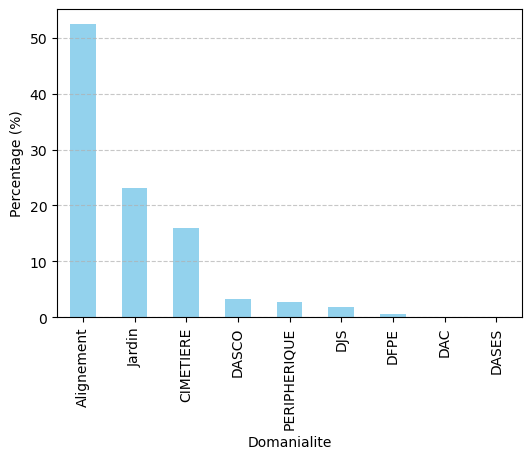

In [62]:
value_counts = df01['domanialite'].value_counts(normalize=True) * 100  # Normalize to get percentages

# Create a bar plot
plt.figure(figsize=(6, 4))  # Set the figure size
value_counts.plot(kind='bar', color='skyblue', alpha=0.9)
plt.xlabel("Domanialite")  # Label for the x-axis
plt.ylabel("Percentage (%)")  # Label for the y-axis
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better visualization
plt.show()  # Display the plot



* A (Adulte) : Cela représente des arbres entièrement développés ou adultes, ayant atteint leur pleine croissance.
* AJ (Arbre Jeune) : Signifie "arbre jeune". Ces arbres sont en développement mais ne sont pas encore matures.
* J (Jeune) : Abbreviation pour "jeune", généralement utilisée pour désigner des jeunes arbres ou des plants (saplings).
* M (Mature) : Indique des arbres matures, mais peut-être pas aussi âgés ou grands que les arbres adultes (parfois similaire à "Adulte").

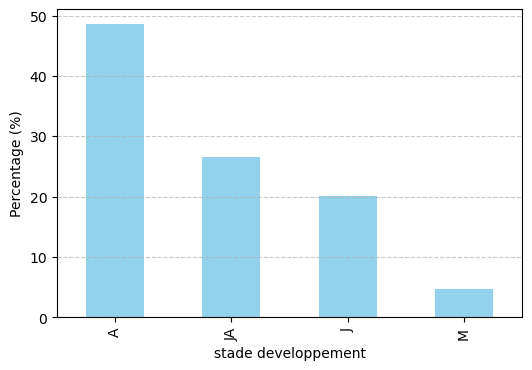

In [27]:
# Generate the value counts as percentages
value_counts = df01['stade_developpement'].value_counts(normalize=True) * 100  # Normalize to get percentages

# Create a bar plot
plt.figure(figsize=(6, 4))  # Set the figure size
value_counts.plot(kind='bar', color='skyblue', alpha=0.9)  # Bar plot with customization
#plt.title("Frequency Plot for 'domanialite' (Percentage Scale)")  # Title for the plot
plt.xlabel("stade developpement")  # Label for the x-axis
plt.ylabel("Percentage (%)")  # Label for the y-axis
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better visualization
plt.show()  # Display the plot

<Figure size 1000x600 with 0 Axes>

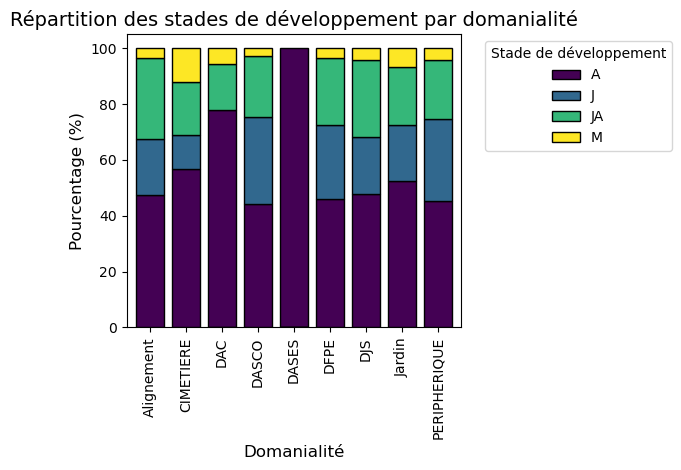

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the percentage distribution of 'stade_developpement' within each 'domanialite'
percentage_data = df01.groupby('domanialite')['stade_developpement'].value_counts(normalize=True).mul(100).unstack()

# Sort or rearrange the data as necessary
percentage_data = percentage_data.fillna(0)  # Replace NaN values with 0 for visualization

# Plot the stacked bar chart
plt.figure(figsize=(10, 6))  # Set figure size
percentage_data.plot(
    kind='bar', 
    stacked=True, 
    colormap='viridis', 
    edgecolor='black', 
    width=0.8
)

# Enhance plot aesthetics
plt.title("Répartition des stades de développement par domanialité", fontsize=14)
plt.xlabel("Domanialité", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)
plt.legend(title="Stade de développement", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


In [29]:
# Extract unique values from 'libelle_francais'
libelle_list = df01['libelle_francais'].unique().tolist()
libelle_list_sorted = sorted([str(item) for item in libelle_list if str(item) != 'nan'])
print("\nValeurs uniques dans 'libelle_francais':")
print(libelle_list_sorted)
print(f"\nNombre de valeurs uniques: {len(libelle_list_sorted)}")


Valeurs uniques dans 'libelle_francais':
['Abelia', 'Abricotier', 'Ailante', 'Alangium', 'Alisier', 'Althéa', 'Amandier', 'Amla', 'Amélanchier', 'Andromède', 'Angélique', 'Araucaria', 'Arbousier', 'Arbre aux mouchoirs', 'Arbre aux quarante écus', 'Arbre de Judée', 'Arbre à Gutta-Percha', 'Arbre à caramel', 'Arbre à miel', 'Arbre à perruque', 'Arbre à soie', 'Argousier', 'Aronie', 'Asiminier', 'Aubepine', 'Aubépine', 'Aulne', 'Bouleau', 'Buis', 'Cabrillet', 'Callistemon', 'Camphrier', 'Caragana', 'Caryer', 'Catalpa', 'Cedrele', 'Cerisier à fleurs', 'Cerisier à fruits', 'Cerisier à grappes', 'Charme', 'Charme-Houblon', 'Chicot du Canada', 'Chimonanthe', 'Chitalpa', 'Châtaignier', 'Chèvrefeuille', 'Chêne', 'Citronnier', 'Clerodendron', 'Cognassier', 'Copalme', 'Cordyline', 'Cormier', 'Cornouiller', 'Cotoneaster', 'Cryptomeria', 'Cunninghamia', 'Cyprès', 'Cyprès Chauve', 'Cytise', 'Cèdre', 'Céphalotaxe', 'Distylium', 'Eleagnus - Chalef', 'Epicéa', 'Erable', 'Eucalyptus', 'Euscaphis', 'Fau

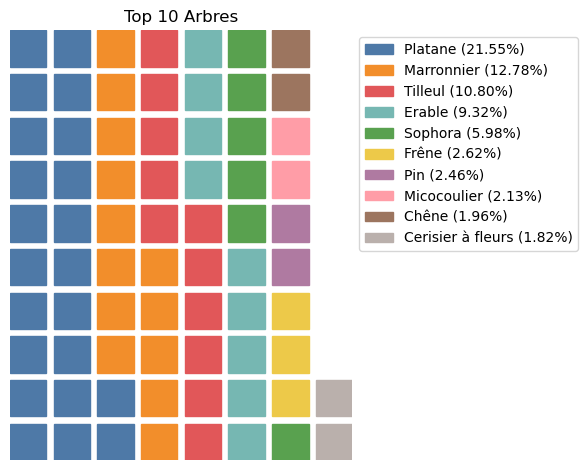

In [30]:
from pywaffle import Waffle
# Extract unique values from 'libelle_francais'
libelle_list = df01['libelle_francais'].unique().tolist()
libelle_list_sorted = sorted([str(item) for item in libelle_list if str(item) != 'nan'])

# Prepare data for the waffle plot (top 10 values for simplicity)
value_counts = df01['libelle_francais'].value_counts(normalize=True)[:10]  # Top 10 values in percentages
data = (value_counts * 100).to_dict()  # Convert to dictionary and scale to percentages

# Create the waffle plot
fig = plt.figure(
    FigureClass=Waffle,
    rows=10,  # Number of rows in the waffle plot
    values=data,
    labels=[f"{k} ({v:.2f}%)" for k, v in data.items()],  # Add labels with percentages
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    colors=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc949", "#af7aa1", "#ff9da7", "#9c755f", "#bab0ac"],
)
plt.title("Top 10 Arbres")
plt.show()

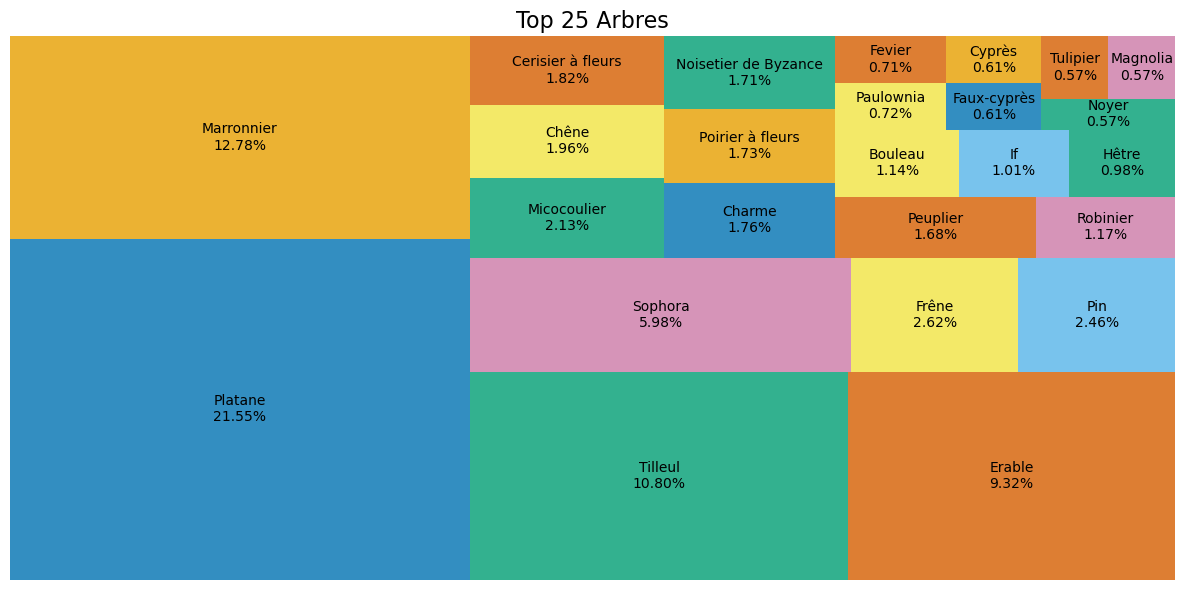

In [31]:
# Prepare data for the treemap (top 10 values in percentages)
value_counts = df01['libelle_francais'].value_counts(normalize=True)[:25]  # Top 10 values in percentages
data = (value_counts * 100).to_dict()  # Convert to dictionary and scale to percentages

# Prepare labels and values
labels = [f"{k}\n{v:.2f}%" for k, v in data.items()]  # Labels with percentages
sizes = list(data.values())  # Sizes for treemap

# Create the Treemap
plt.figure(figsize=(12, 6))  # Set figure size
squarify.plot(
    sizes=sizes, 
    label=labels, 
    alpha=0.8, 
    color=["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442", "#56B4E9", "#009E73", "#F0E442", "#D55E00"]  # Colorblind-friendly palette
)
plt.title("Top 25 Arbres", fontsize=16)
plt.axis('off')  # Remove axes for better display
plt.tight_layout()

# Show the plot
plt.show()


*pip install squarify* - if you do not have it

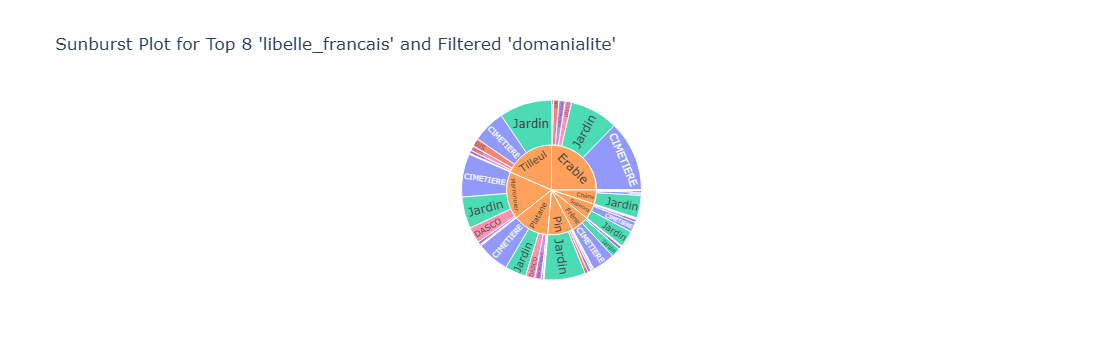

In [66]:
# Step 1: Filter the DataFrame to exclude rows where 'domanialite' equals 'alignement'
df02 = df01[df01['domanialite'] != 'Alignement']

# Step 2: Extract top 10 values from 'libelle_francais'
top_8_values = df02['libelle_francais'].value_counts()[:8].index.tolist()

# Step 3: Filter df01 to include only rows where 'libelle_francais' is in the top 10 values
filtered_df02 = df02[df02['libelle_francais'].isin(top_8_values)]

# Step 4: Create the sunburst plot
fig = px.sunburst(
    filtered_df02,
    path=['libelle_francais', 'domanialite'],  # Hierarchical structure
    title="Sunburst Plot for Top 8 'libelle_francais' and Filtered 'domanialite'",
    color='domanialite',  # Differentiate by 'domanialite'
)

# Step 5: Show the plot
fig.show()

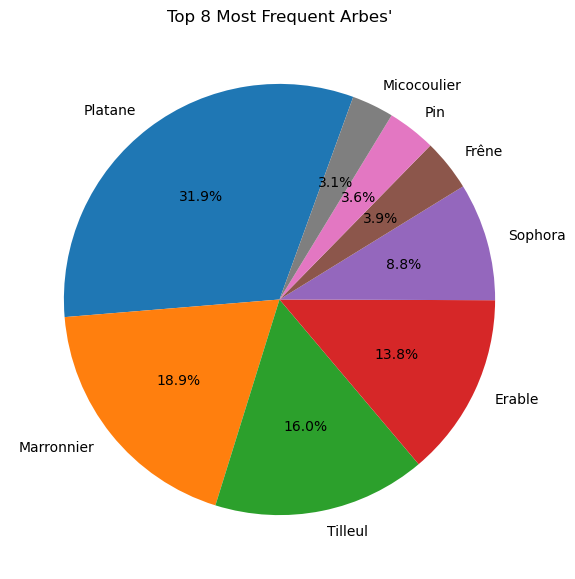

In [80]:
# Extract the top 8 most frequent values in 'libelle_francais'
top_8_values = df01['libelle_francais'].value_counts()[:8]

# Create a pie plot
plt.figure(figsize=(7, 7))  # Set the figure size
top_8_values.plot(kind='pie', autopct='%1.1f%%', startangle=70, colors=plt.cm.tab10.colors)  # Pie chart
plt.title("Top 8 Most Frequent Arbes'")  # Add a title
plt.ylabel("")  # Remove the y-axis label for aesthetics
plt.show()  # Display the plot

pip install pywaffle

In [36]:
custom_order = [
    'PARIS 1ER ARRDT', 'PARIS 2E ARRDT', 'PARIS 3E ARRDT', 'PARIS 4E ARRDT',
    'PARIS 5E ARRDT', 'PARIS 6E ARRDT', 'PARIS 7E ARRDT', 'PARIS 8E ARRDT',
    'PARIS 9E ARRDT', 'PARIS 10E ARRDT', 'PARIS 11E ARRDT', 'PARIS 12E ARRDT',
    'PARIS 13E ARRDT', 'PARIS 14E ARRDT', 'PARIS 15E ARRDT', 'PARIS 16E ARRDT',
    'PARIS 17E ARRDT', 'PARIS 18E ARRDT', 'PARIS 19E ARRDT', 'PARIS 20E ARRDT',
    'BOIS DE BOULOGNE', 'BOIS DE VINCENNES', 'HAUTS-DE-SEINE',
    'SEINE-SAINT-DENIS', 'VAL-DE-MARNE'
]
df01.loc[:, 'arrondissement'] = pd.Categorical(df01['arrondissement'], categories=custom_order, ordered=True)
df01['arrondissement'] = pd.Categorical(
    df01['arrondissement'], 
    categories=custom_order, 
    ordered=True
)

In [37]:
df01.shape

(197252, 16)

<Figure size 500x300 with 0 Axes>

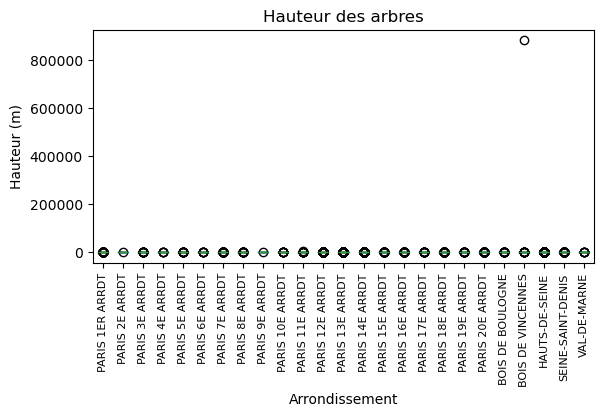

In [38]:
# Create a more compact boxplot for 'hauteur_m' by 'arrondissement'
plt.figure(figsize=(5, 3))  # Reduced figure size
df01.boxplot(column='hauteur_m', by='arrondissement', grid=False)

# Rotating x-axis labels for better readability
plt.xticks(rotation=90, fontsize=8)  # Reduced font size for x-axis labels

# Enhancing the plot with titles and labels
plt.title('Hauteur des arbres', fontsize=12)  # Reduced title font size
plt.suptitle('')  # Remove the default super title
plt.xlabel('Arrondissement', fontsize=10)  # Reduced font size
plt.ylabel('Hauteur (m)', fontsize=10)  # Reduced font size
plt.tight_layout(pad=2)  # Adjust padding to make the plot more compact

# Display the plot
plt.show()


In [39]:
df01.shape

(197252, 16)

In [40]:
# Quantile-based data filtering (to remove outliers)
lower_threshold = df01['hauteur_m'].quantile(0.000)
upper_threshold = df01['hauteur_m'].quantile(0.997)
df01_cleaned = df01[(df01['hauteur_m'] > lower_threshold) & (df01['hauteur_m'] <= upper_threshold)]

print("\nDimensions après nettoyage (sans valeurs aberrantes):")
print(df01_cleaned.shape)


Dimensions après nettoyage (sans valeurs aberrantes):
(158110, 16)


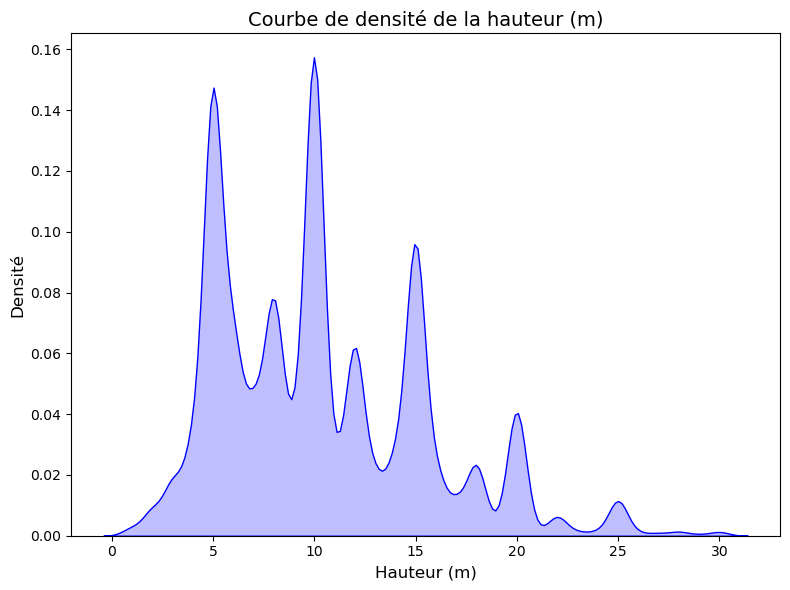

In [41]:
import seaborn as sns
# Trace un graphique de densité pour 'hauteur_m'
plt.figure(figsize=(8, 6))  # Définir la taille du graphique
sns.kdeplot(df01_cleaned['hauteur_m'], fill=True, color='blue')  # Utiliser Seaborn pour une visualisation douce de la densité
plt.title('Courbe de densité de la hauteur (m)', fontsize=14)  # Titre du graphique
plt.xlabel('Hauteur (m)', fontsize=12)  # Libellé de l'axe des x
plt.ylabel('Densité', fontsize=12)  # Libellé de l'axe des y
plt.tight_layout()  # Ajuster la mise en page
plt.show()

<Figure size 600x400 with 0 Axes>

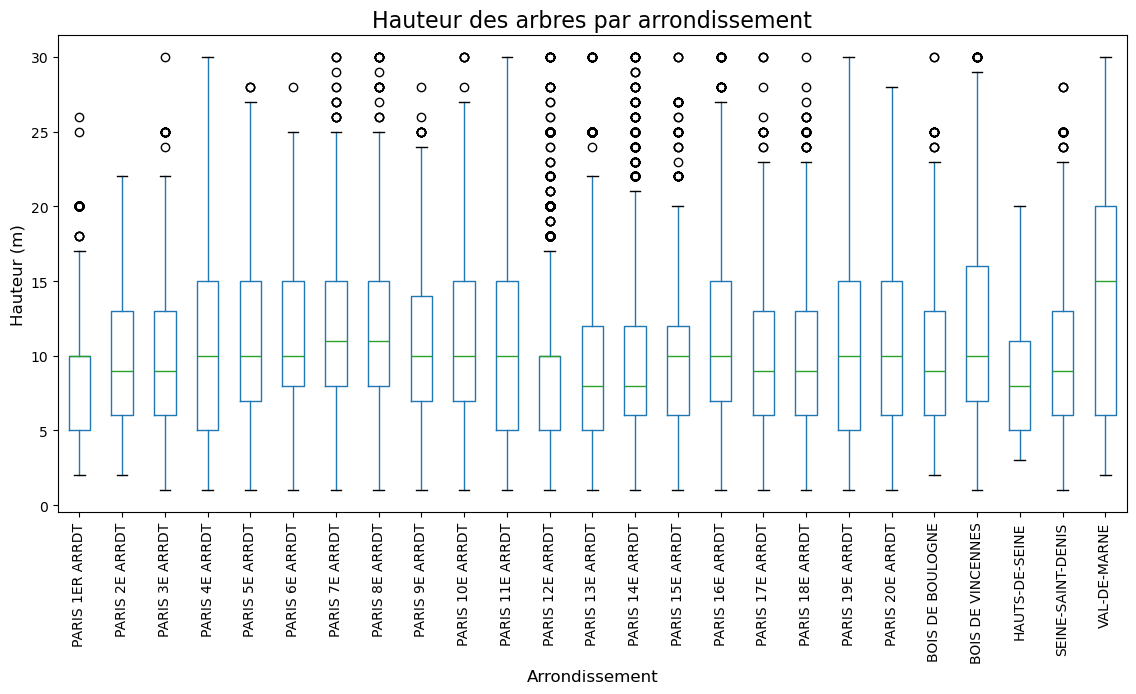

In [42]:
# Step 2: Convert the 'arrondissement' column to follow the custom order
# Explicitly use .loc to assign the custom order
df01_cleaned.loc[:, 'arrondissement'] = pd.Categorical(
    df01_cleaned['arrondissement'], 
    categories=custom_order, 
    ordered=True
)

# Step 3: Create a boxplot for 'hauteur_m' by 'arrondissement'
plt.figure(figsize=(6, 4))  # Set the figure size
df01_cleaned.boxplot(column='hauteur_m', by='arrondissement', grid=False, figsize=(12, 8), rot=90)

# Step 4: Enhance the plot
plt.title('Hauteur des arbres par arrondissement', fontsize=16)
plt.suptitle('')  # Remove the default super title
plt.xlabel('Arrondissement', fontsize=12)
plt.ylabel('Hauteur (m)', fontsize=12)
plt.tight_layout(pad=3)  # Adjust padding to make the plot more compact
# Step 5: Display the plot
plt.show()


<Figure size 1400x800 with 0 Axes>

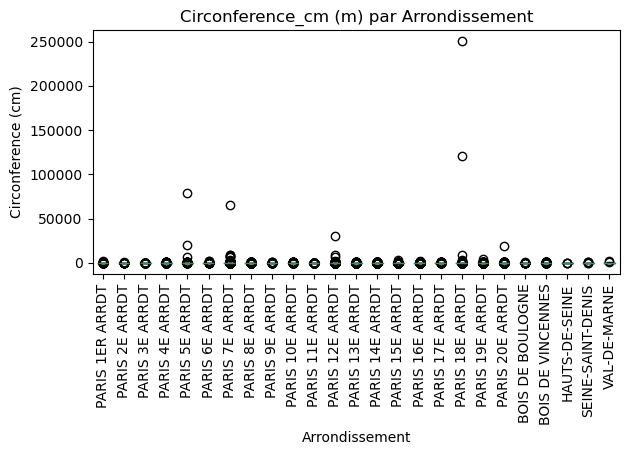

In [43]:
plt.figure(figsize=(14, 8))
df01_cleaned.boxplot(column='circonference_cm', by='arrondissement', grid=False)

plt.title('Circonference_cm (m) par Arrondissement')
plt.suptitle('')  # Remove the default subtitle
plt.xlabel('Arrondissement')
plt.ylabel('Circonference (cm)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [44]:
# Quantile-based data filtering (to remove outliers)
lower_threshold = df01_cleaned['circonference_cm'].quantile(0.003)
upper_threshold = df01_cleaned['circonference_cm'].quantile(0.997)

# Ensure alignment between the filtering condition and the DataFrame index
df02_cleaned = df01_cleaned.loc[
    (df01_cleaned['circonference_cm'] > 0) & 
    (df01_cleaned['circonference_cm'] <= upper_threshold)
]

# Print the dimensions of the cleaned DataFrame
print("\nDimensions après nettoyage (sans valeurs aberrantes):")
print(df02_cleaned.shape)



Dimensions après nettoyage (sans valeurs aberrantes):
(157293, 16)


<Figure size 1400x800 with 0 Axes>

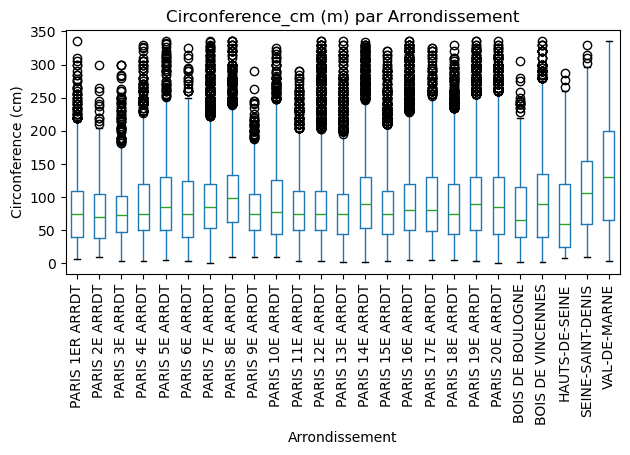

In [45]:
plt.figure(figsize=(14, 8))
df02_cleaned.boxplot(column='circonference_cm', by='arrondissement', grid=False)

plt.title('Circonference_cm (m) par Arrondissement')
plt.suptitle('')  # Remove the default subtitle
plt.xlabel('Arrondissement')
plt.ylabel('Circonference (cm)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

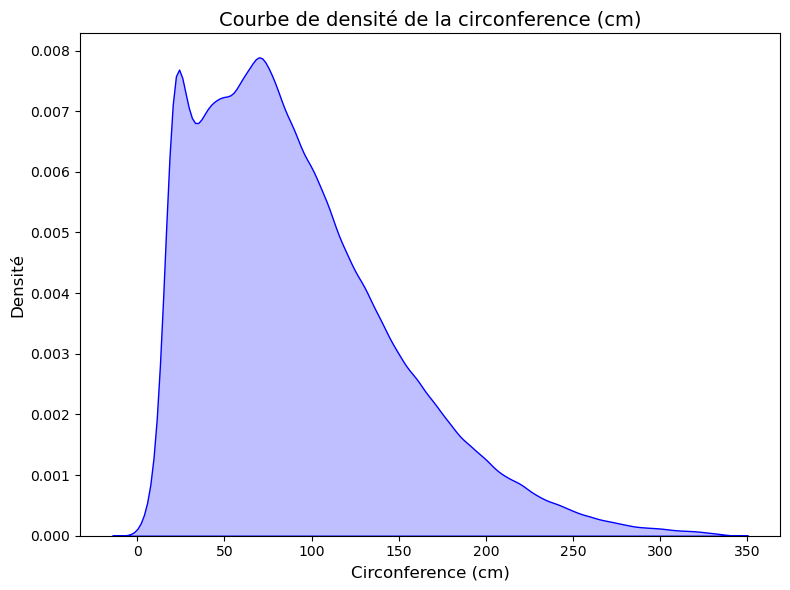

In [46]:
# Trace un graphique de densité pour 'hauteur_m'
plt.figure(figsize=(8, 6))  # Définir la taille du graphique
sns.kdeplot(df02_cleaned['circonference_cm'], fill=True, color='blue')  # Utiliser Seaborn pour une visualisation douce de la densité
plt.title('Courbe de densité de la circonference (cm)', fontsize=14)  # Titre du graphique
plt.xlabel('Circonference (cm)', fontsize=12)  # Libellé de l'axe des x
plt.ylabel('Densité', fontsize=12)  # Libellé de l'axe des y
plt.tight_layout()  # Ajuster la mise en page
plt.show()

In [47]:
df02_cleaned.describe()

,id,circonference_cm,hauteur_m,remarquable,geo_point_2d_a,geo_point_2d_b
count,1.572930e+05,157293.000000,157293.000000,124957.000000,157293.000000,157293.000000
mean,3.764360e+05,92.068382,10.361644,0.000920,48.855817,2.346087
std,5.128620e+05,56.607525,5.085739,0.030323,0.025890,0.049381
min,9.987400e+04,1.000000,1.000000,0.000000,48.742290,2.210416
25%,1.872260e+05,50.000000,6.000000,0.000000,48.836806,2.307392
50%,2.327440e+05,80.000000,10.000000,0.000000,48.855174,2.348675
75%,2.766930e+05,125.000000,14.000000,0.000000,48.874042,2.383230
max,2.023468e+06,335.000000,30.000000,1.000000,48.911485,2.469759


In [48]:
remarkable_filtered = df02_cleaned[df02_cleaned['remarquable'] == 1]
remarkable_filtered.head()

,id,type_emplacement,domanialite,arrondissement,lieu,id_emplacement,libelle_francais,genre,espece,variete,circonference_cm,hauteur_m,stade_developpement,remarquable,geo_point_2d_a,geo_point_2d_b
1867,102027,Arbre,Jardin,PARIS 19E ARRDT,PARC DES BUTTES CHAUMONT,G0380001,Marronnier,Aesculus,hippocastanum,NaN,330,22,M,1.0,48.880080,2.385710
1868,102028,Arbre,Jardin,PARIS 19E ARRDT,PARC DES BUTTES CHAUMONT,G0380002,Marronnier,Aesculus,hippocastanum,NaN,323,25,M,1.0,48.880116,2.385667
1889,102053,Arbre,Jardin,PARIS 19E ARRDT,PARC DES BUTTES CHAUMONT,G0310005,Arbre aux quarante écus,Ginkgo,biloba,NaN,270,24,A,1.0,48.882322,2.384088
3223,103916,Arbre,Jardin,PARIS 19E ARRDT,PARC DES BUTTES CHAUMONT,O1020001,If,Taxus,baccata,NaN,140,13,M,1.0,48.877043,2.380500
3955,104839,Arbre,Jardin,PARIS 13E ARRDT,SQUARE RENE LE GALL,10268,Chêne,Quercus,cerris,NaN,130,19,A,1.0,48.833021,2.349915


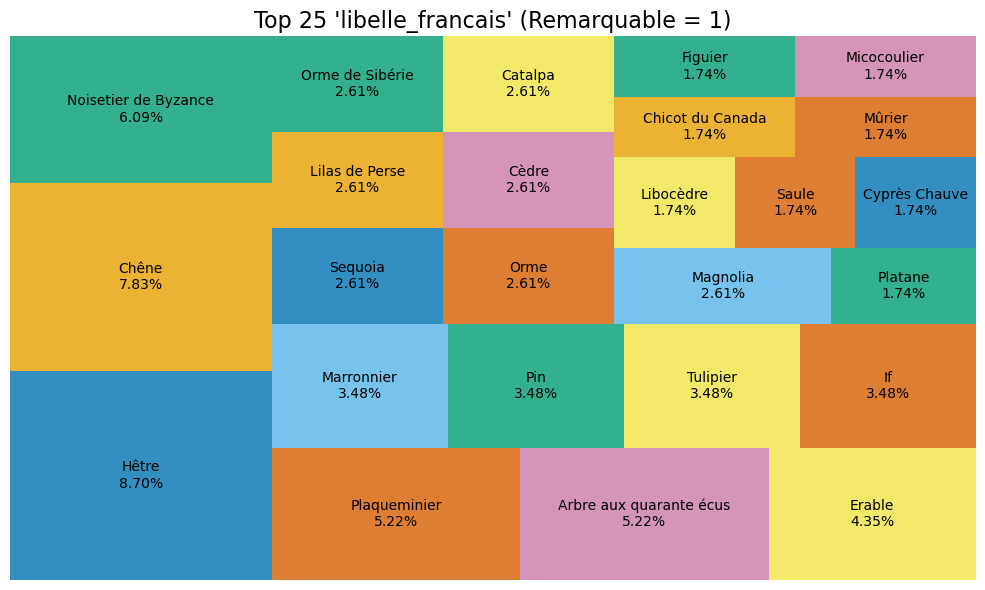

In [49]:
# Prepare data for the treemap (top 10 values in percentages)
value_counts = remarkable_filtered['libelle_francais'].value_counts(normalize=True)[:25]  # Top 10 values in percentages
data = (value_counts * 100).to_dict()  # Convert to dictionary and scale to percentages

# Prepare labels and sizes
labels = [f"{k}\n{v:.2f}%" for k, v in data.items()]  # Labels with percentages
sizes = list(data.values())  # Sizes for treemap

# Create the Treemap
plt.figure(figsize=(10, 6))  # Set figure size
squarify.plot(
    sizes=sizes, 
    label=labels, 
    alpha=0.8, 
    color=["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442", "#56B4E9", "#009E73", "#F0E442", "#D55E00"]  # Colorblind-friendly palette
)
plt.title("Top 25 'libelle_francais' (Remarquable = 1)", fontsize=16)
plt.axis('off')  # Remove axes for better display
plt.tight_layout()

# Show the plot
plt.show()


In [54]:
# Initialize a map centered around the average coordinates
mean_lat = remarkable_filtered['geo_point_2d_a'].mean()
mean_lon = remarkable_filtered['geo_point_2d_b'].mean()
map_ = folium.Map(location=[mean_lat, mean_lon], zoom_start=12)

# Add marker cluster for grouping points
marker_cluster = MarkerCluster().add_to(map_)

# Group data by 'libelle_francais' and add markers
for _, row in remarkable_filtered.iterrows():
    libelle = row['libelle_francais']  # Group label
    lat = row['geo_point_2d_a']
    lon = row['geo_point_2d_b']
    
    if pd.notna(lat) and pd.notna(lon):  # Check for valid coordinates
        folium.Marker(
            location=[lat, lon],
            popup=f"Libellé Français: {libelle}",
            icon=folium.Icon(color="blue")
        ).add_to(marker_cluster)

# Display the map inline in the notebook
map_



In [52]:
import folium

# Initialize a map centered around Paris
paris_lat, paris_lon = 48.8566, 2.3522  # Coordinates of Paris
map_paris = folium.Map(location=[paris_lat, paris_lon], zoom_start=12)

# Add Paris arrondissements boundaries using your GeoJSON file
geojson_path = "arrondissements-75-paris.geojson"
folium.GeoJson(
    geojson_path,
    name="Arrondissements",
    style_function=lambda feature: {
        'color': 'blue',  # Border color
        'weight': 2,      # Border thickness
        'fillOpacity': 0.1  # Transparency for the fill
    }
).add_to(map_paris)

# Add markers for remarkable points
for _, row in remarkable_filtered.iterrows():
    lat = row['geo_point_2d_a']
    lon = row['geo_point_2d_b']
    libelle = row['libelle_francais']
    
    if pd.notna(lat) and pd.notna(lon):  # Ensure valid coordinates
        folium.Marker(
            location=[lat, lon],
            popup=f"Libellé Français: {libelle}",
            icon=folium.Icon(color='red')  # Use red markers for clarity
        ).add_to(map_paris)

# Display the map inline in your Jupyter Notebook
map_paris


pip install geopandas